In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print("TensorFlow :", tf.__version__)

TensorFlow : 2.21.0


In [4]:
train_csv = "rambu/Train.csv"

df = pd.read_csv(train_csv)

print(df.head())
print(df.shape)

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  
(39209, 8)


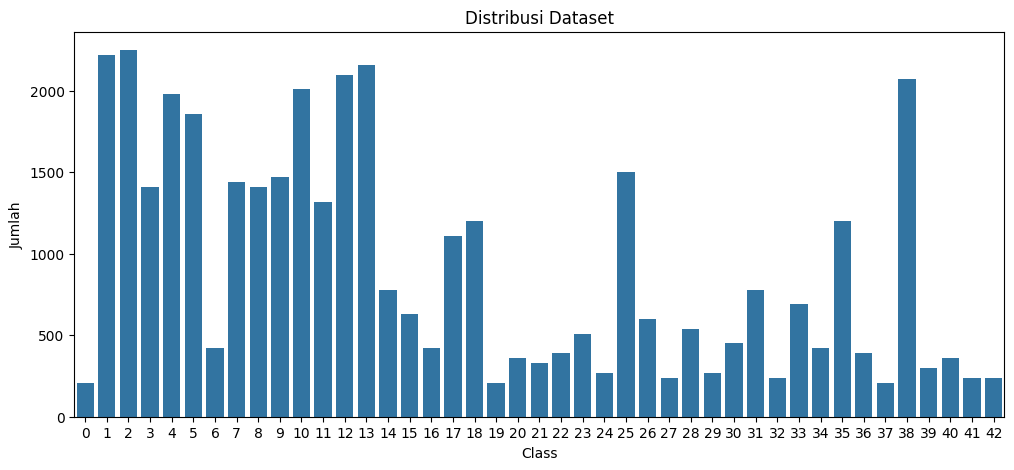

In [5]:
plt.figure(figsize=(12,5))

sns.countplot(x=df["ClassId"])

plt.title("Distribusi Dataset")
plt.xlabel("Class")
plt.ylabel("Jumlah")

plt.show()

In [6]:
IMG_SIZE = 48

images = []
labels = []

for _, row in df.iterrows():

    img_path = os.path.join(
        "rambu",
        row["Path"]
    )

    image = cv2.imread(img_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    images.append(image)
    labels.append(row["ClassId"])

X = np.array(images, dtype=np.float32)
y = np.array(labels)

print(X.shape)
print(y.shape)

(39209, 48, 48, 3)
(39209,)


In [7]:
X = preprocess_input(X)

print(X.min())
print(X.max())

-123.68
151.061


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(31367, 48, 48, 3)
(7842, 48, 48, 3)


In [11]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(48,48,3)
)

base_model.trainable = False

print(base_model.summary())

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 53s 1us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

None


In [12]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

output = Dense(
    43,
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.compile(
    optimizer=Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,857,067 (56.68 MB)

 Trainable params: 142,379 (556.17 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [13]:
callbacks = [

    EarlyStopping(
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        patience=3,
        factor=0.3
    ),

    ModelCheckpoint(
        "best_vgg16.keras",
        save_best_only=True
    )

]

In [15]:
history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=20,

    batch_size=32,

    callbacks=callbacks

)

Epoch 1/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 267s 338ms/step - accuracy: 0.1445 - loss: 11.7000 - val_accuracy: 0.3441 - val_loss: 3.2417 - learning_rate: 1.0000e-04
Epoch 2/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 258s 328ms/step - accuracy: 0.2697 - loss: 3.9553 - val_accuracy: 0.4190 - val_loss: 2.2634 - learning_rate: 1.0000e-04
Epoch 3/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 264s 336ms/step - accuracy: 0.3348 - loss: 2.7518 - val_accuracy: 0.4809 - val_loss: 1.9090 - learning_rate: 1.0000e-04
Epoch 4/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 261s 333ms/step - accuracy: 0.4081 - loss: 2.2638 - val_accuracy: 0.5316 - val_loss: 1.6631 - learning_rate: 1.0000e-04
Epoch 5/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 261s 332ms/step - accuracy: 0.4545 - loss: 1.9562 - val_accuracy: 0.5789 - val_loss: 1.4616 - learning_rate: 1.0000e-04
Epoch 6/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 258s 328ms/step - accuracy: 0.5032 - loss: 1.7336 - val_accuracy: 0.6175 - val_loss: 1.2974 - learning_rate: 1.0000e-04
Epoch 7/20
785/785 ━━━━━━━━━━━━━━━━━━━━

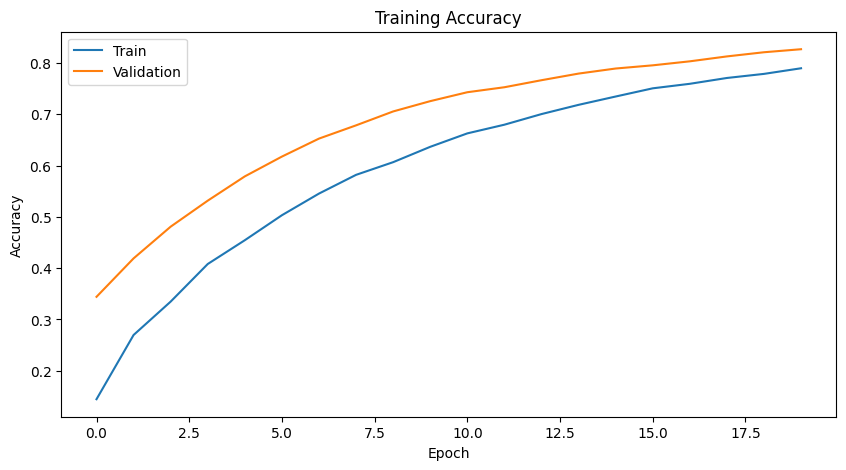

In [16]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["accuracy"],
    label="Train"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.legend()

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.show()

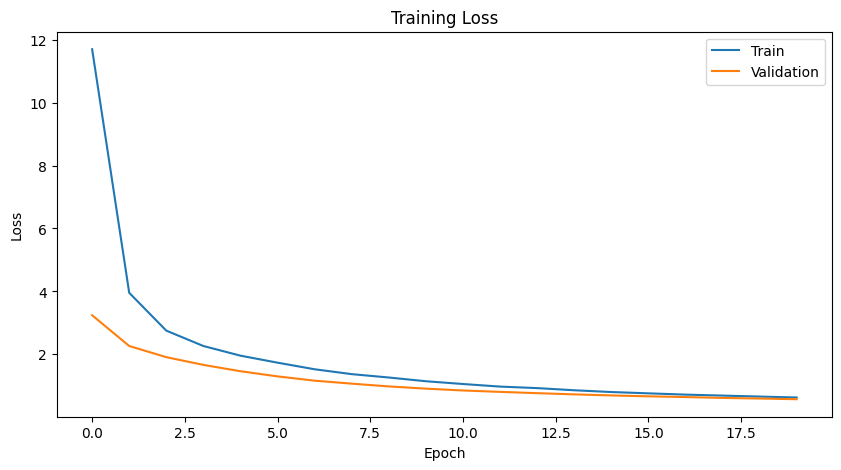

In [17]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Train"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.legend()

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss")

plt.show()

In [18]:
loss, acc = model.evaluate(
    X_test,
    y_test
)

print("Accuracy :", acc)
print("Loss :", loss)

246/246 ━━━━━━━━━━━━━━━━━━━━ 66s 270ms/step - accuracy: 0.8235 - loss: 0.5697
Accuracy : 0.8235144019126892
Loss : 0.5697491765022278


In [19]:
prediction = model.predict(X_test)

pred_class = np.argmax(
    prediction,
    axis=1
)

print(

    classification_report(

        y_test,
        pred_class

    )

)

246/246 ━━━━━━━━━━━━━━━━━━━━ 75s 302ms/step
              precision    recall  f1-score   support

           0       0.88      0.67      0.76        42
           1       0.74      0.77      0.76       444
           2       0.71      0.76      0.73       450
           3       0.68      0.65      0.67       282
           4       0.76      0.73      0.74       396
           5       0.72      0.75      0.74       372
           6       0.96      0.95      0.96        84
           7       0.83      0.79      0.81       288
           8       0.81      0.72      0.76       282
           9       0.91      0.90      0.91       294
          10       0.90      0.94      0.92       402
          11       0.70      0.82      0.76       264
          12       0.93      0.98      0.96       420
          13       0.95      0.98      0.97       432
          14       0.97      0.99      0.98       156
          15       0.99      0.91      0.95       126
          16       0.98      0.99    

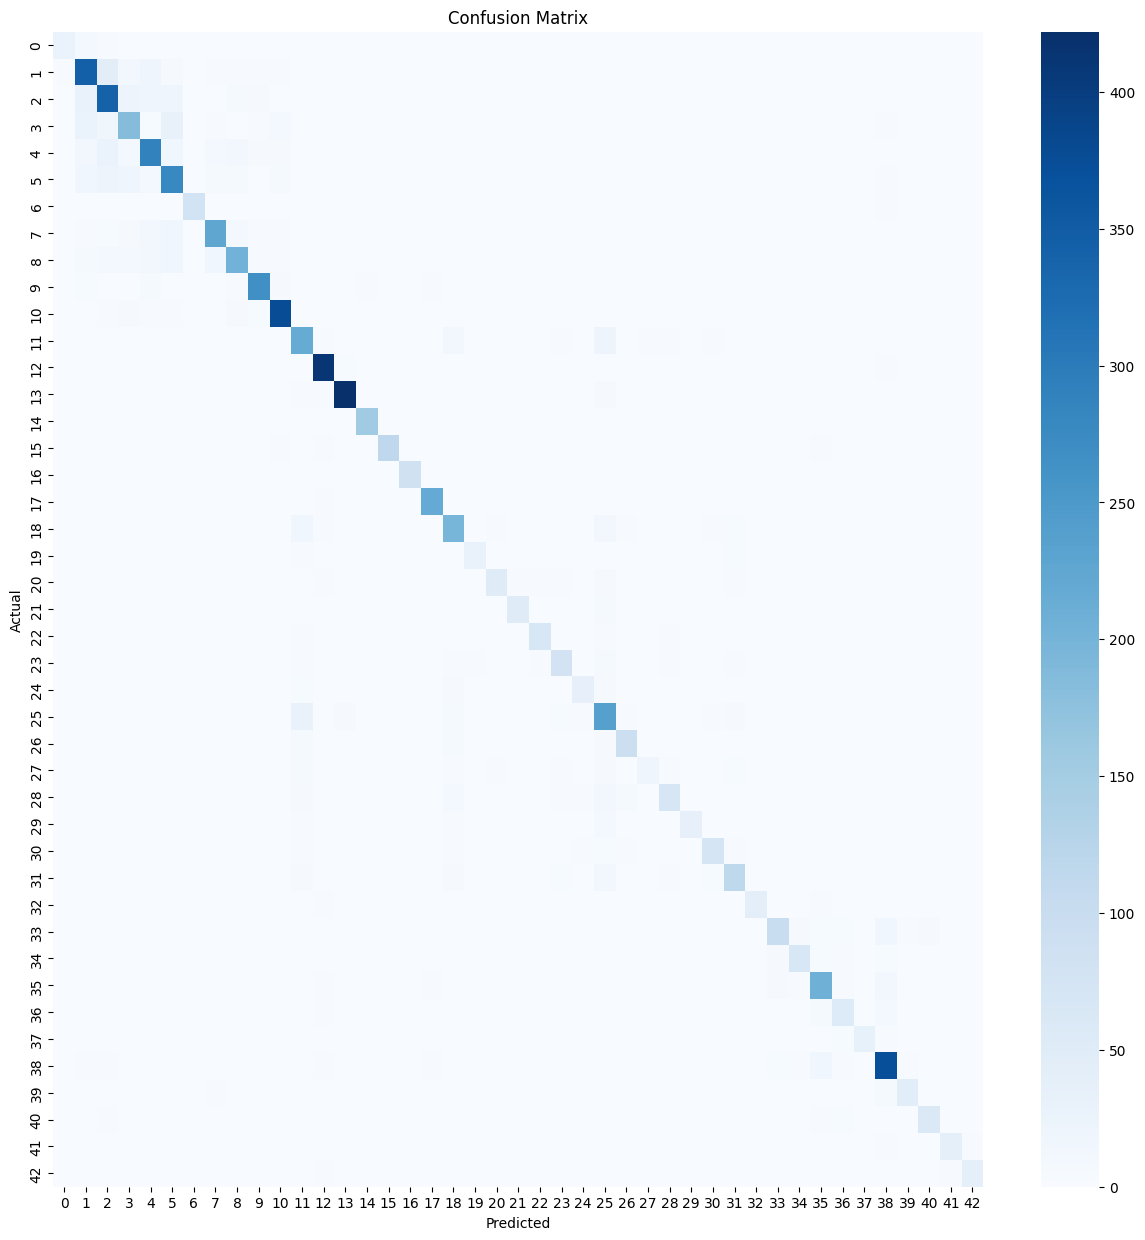

In [21]:
cm = confusion_matrix(
    y_test,
    pred_class
)

plt.figure(figsize=(15,15))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [22]:
model.save("gtsrb_vgg16.keras")

print("Model berhasil disimpan.")

Model berhasil disimpan.
